In [159]:
import sys
#sys.path.append(r'C:\Program Files (x86)\MLRPlotting\MLRPlotting')
#print(sys.path)
import matplotlib.pyplot as plt
from MLRPlotting import static_plotter
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

In [160]:
help(matplotlib)

NameError: name 'matplotlib' is not defined

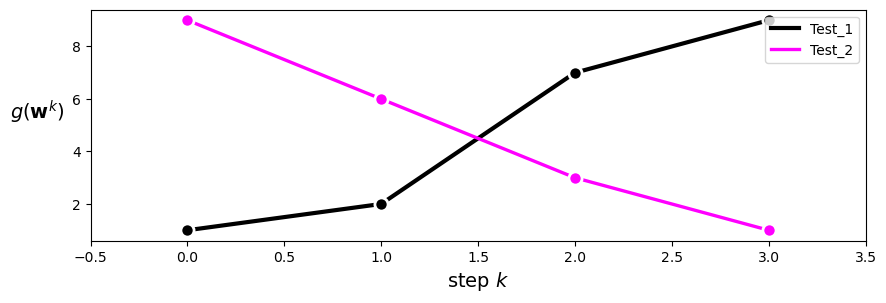

In [141]:
# import custom plotting tools
static_plotter = static_plotter.Visualizer();

cost_1 = [1,2,7,9]
cost_2 = [9,6,3,1]
# plot the cost function history for two runs
static_plotter.plot_cost_histories([cost_1,cost_2],start=0,points=True,labels=[r'Test_1',r'Test_2'])

In [49]:
num_samples=2
D=4
directions=np.random.randn(num_samples,D)
print(directions)
print('the norm of a direction is:',np.linalg.norm(directions[0]))

[[ 0.11666042  1.44386705 -0.1960909  -0.77833972]
 [ 0.7208601   0.68234996 -0.7441348  -0.80305358]]
the norm of a direction is: 1.6560875775730253


In [50]:
directions*directions

array([[0.01360965, 2.08475205, 0.03845164, 0.60581272],
       [0.51963928, 0.46560146, 0.5537366 , 0.64489504]])

In [57]:
print(np.sum(directions*directions),
np.sum(directions*directions,axis=0),
np.sum(directions*directions,axis=1))


2.0 [0.24290625 0.97332983 0.26757722 0.5161867 ] [1. 1.]
[[ 0.07044339  0.87185428 -0.11840612 -0.46998705]
 [ 0.48779501  0.46173579 -0.50354465 -0.54341409]]


In [58]:
psum=np.sum(directions*directions,axis=1)
norms=np.sqrt(psum)
norms.shape=(num_samples,1)
directions = directions/norms
print(directions,np.sum(directions*directions,axis=1))

[[ 0.07044339  0.87185428 -0.11840612 -0.46998705]
 [ 0.48779501  0.46173579 -0.50354465 -0.54341409]] [1. 1.]


In [62]:
w=np.array([3,4])
np.dot(w.T,w)

25

In [85]:
def random_search(g,alpha_choice,max_its,w,num_samples):
    w_history = []         # container for w history
    cost_history = []           # container for corresponding cost function history
    alpha = 0
    
    for k in range(1,max_its+1):
        # check if diminishing steplength rule used
        if alpha_choice == 'diminishing':
            alpha = 1/float(k)
        else:
            alpha = alpha_choice

        directions=np.random.randn(num_samples,len(w))
        psum=np.sum(directions*directions,axis=1)
        norms=np.sqrt(psum)
        norms.shape=(num_samples,1)
        directions = directions/norms
        w_candidates=w + alpha*directions
        gvals=[g(wval) for wval in w_candidates]
        ind=np.argmin(gvals)
        if g(w_candidates[ind])<g(w):
            w_history.append(w_candidates[ind])
            cost_history.append(g(w_candidates[ind]))
            w=w_candidates[ind]
    return w_history,cost_history

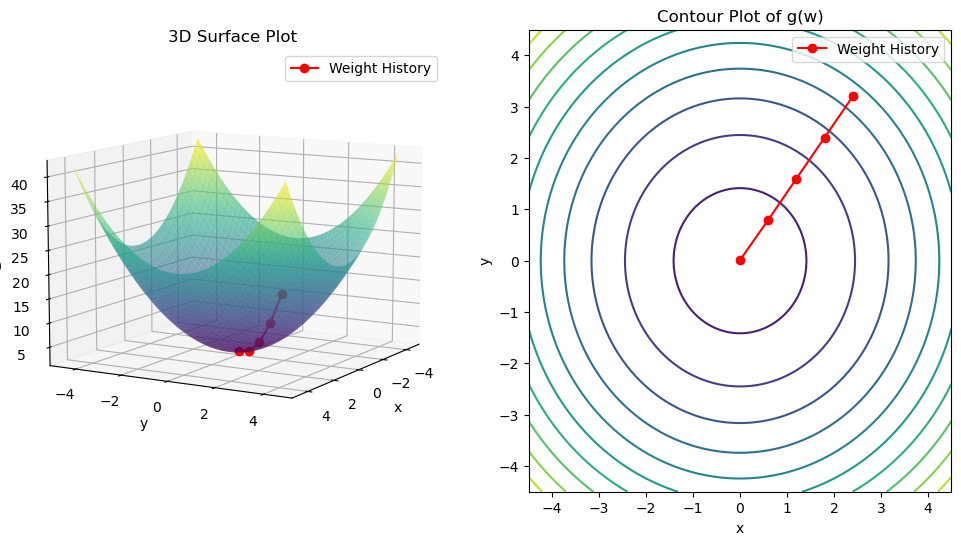

In [100]:
g = lambda w: np.dot(w.T,w) + 2
alpha_choice = 1; w = np.array([3,4]); num_samples = 1000; max_its = 5;
weight_history,cost_history = random_search(g,alpha_choice,max_its,w,num_samples)
#static_plotter.two_input_surface_contour_plot(g,weight_history,view = [10,30],xmin = -4.5, xmax = 4.5, ymin = -4.5, ymax = 4.5)
x = np.linspace(-4.5, 4.5, 100)
y = np.linspace(-4.5, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.array([g(np.array([x_, y_])) for x_, y_ in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

# Create 3D and contour plots
fig = plt.figure(figsize=(12, 6))

# 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis')
ax1.set_title("3D Surface Plot")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('g(w)')
ax1.view_init(10, 30)

# Overlay weight history
history_x = [w[0] for w in weight_history]
history_y = [w[1] for w in weight_history]
history_z = [g(w) for w in weight_history]
ax1.plot(history_x, history_y, history_z, color='red', marker='o', label='Weight History')
ax1.legend()

# Contour Plot
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=10, cmap='viridis')
ax2.set_title("Contour Plot of g(w)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Overlay weight history
ax2.plot(history_x, history_y, color='red', marker='o', label='Weight History')
ax2.legend()

plt.show()

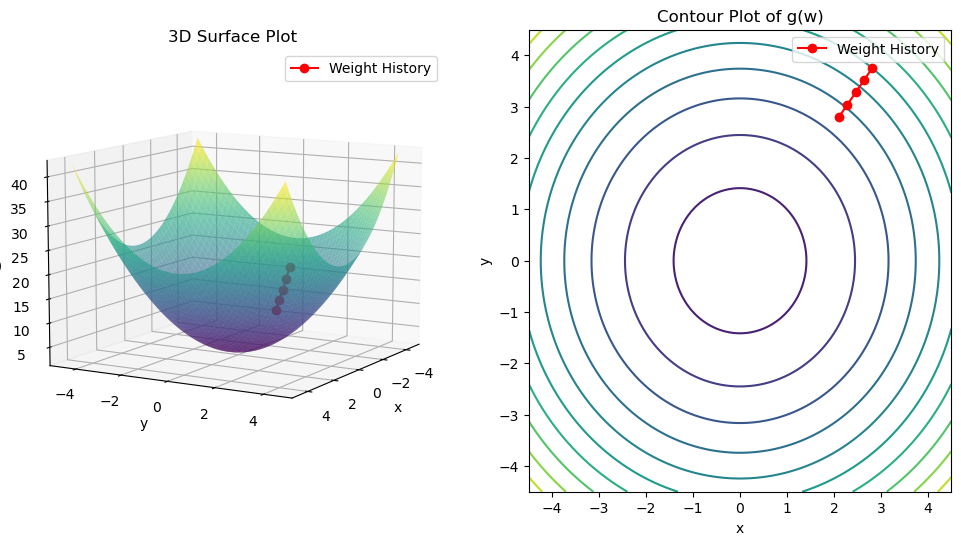

In [87]:
g = lambda w: np.dot(w.T,w) + 2
alpha_choice = 0.3; w = np.array([3,4]); num_samples = 1000; max_its = 5;
weight_history,cost_history = random_search(g,alpha_choice,max_its,w,num_samples)
#static_plotter.two_input_surface_contour_plot(g,weight_history,view = [10,30],xmin = -4.5, xmax = 4.5, ymin = -4.5, ymax = 4.5)
x = np.linspace(-4.5, 4.5, 100)
y = np.linspace(-4.5, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.array([g(np.array([x_, y_])) for x_, y_ in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

# Create 3D and contour plots
fig = plt.figure(figsize=(12, 6))

# 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis')
ax1.set_title("3D Surface Plot")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('g(w)')
ax1.view_init(10, 30)

# Overlay weight history
history_x = [w[0] for w in weight_history]
history_y = [w[1] for w in weight_history]
history_z = [g(w) for w in weight_history]
ax1.plot(history_x, history_y, history_z, color='red', marker='o', label='Weight History')
ax1.legend()

# Contour Plot
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=10, cmap='viridis')
ax2.set_title("Contour Plot of g(w)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Overlay weight history
ax2.plot(history_x, history_y, color='red', marker='o', label='Weight History')
ax2.legend()

plt.show()

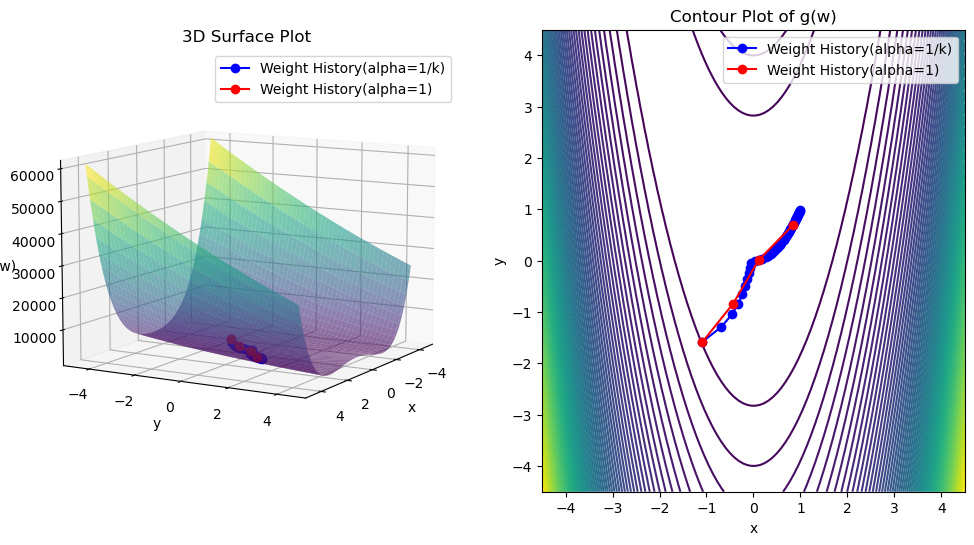

In [105]:
g = lambda w: 100*(w[1] - w[0]**2 )**2 + (w[0] - 1)**2
alpha_choice = 1; w = np.array([-2,-2]); num_samples = 1000; max_its = 50;
weight_history,cost_history = random_search(g,alpha_choice,max_its,w,num_samples)
weight_history_k,cost_history_k = random_search(g,'diminishing',max_its,w,num_samples)
#static_plotter.two_input_surface_contour_plot(g,weight_history,view = [10,30],xmin = -4.5, xmax = 4.5, ymin = -4.5, ymax = 4.5)
x = np.linspace(-4.5, 4.5, 100)
y = np.linspace(-4.5, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.array([g(np.array([x_, y_])) for x_, y_ in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

# Create 3D and contour plots
fig = plt.figure(figsize=(12, 6))

# 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis')
ax1.set_title("3D Surface Plot")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('g(w)')
ax1.view_init(10, 30)

# Overlay weight history
history_x = [w[0] for w in weight_history]
history_y = [w[1] for w in weight_history]
history_z = [c for c in cost_history]
history_x_k = [w[0] for w in weight_history_k]
history_y_k = [w[1] for w in weight_history_k]
history_z_k = [c for c in cost_history_k]
ax1.plot(history_x_k, history_y_k, history_z_k, color='blue', marker='o', label='Weight History(alpha=1/k)')
ax1.plot(history_x, history_y, history_z, color='red', marker='o', label='Weight History(alpha=1)')
ax1.legend()

# Contour Plot
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=100, cmap='viridis')
ax2.set_title("Contour Plot of g(w)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Overlay weight history
ax2.plot(history_x_k, history_y_k, color='blue', marker='o', label='Weight History(alpha=1/k)')
ax2.plot(history_x, history_y, color='red', marker='o', label='Weight History(alpha=1)')
ax2.legend()

plt.show()

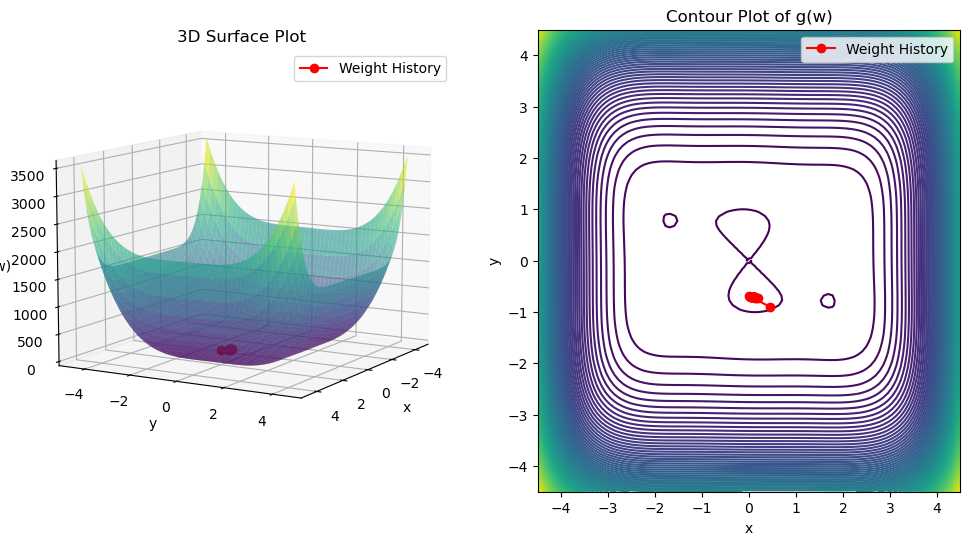

In [108]:
g = lambda w: (4 - 2.1*w[0]**2 + w[0]**4/3)*w[0]**2+ w[1]*w[0] + (-4 + 4*w[1]**2)*w[1]**2
alpha_choice = 'diminishing'; w = np.array([0,0]); num_samples = 1000; max_its = 50;
weight_history,cost_history = random_search(g,alpha_choice,max_its,w,num_samples)
#static_plotter.two_input_surface_contour_plot(g,weight_history,view = [10,30],xmin = -4.5, xmax = 4.5, ymin = -4.5, ymax = 4.5)
x = np.linspace(-4.5, 4.5, 100)
y = np.linspace(-4.5, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.array([g(np.array([x_, y_])) for x_, y_ in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

# Create 3D and contour plots
fig = plt.figure(figsize=(12, 6))

# 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis')
ax1.set_title("3D Surface Plot")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('g(w)')
ax1.view_init(10, 30)

# Overlay weight history
history_x = [w[0] for w in weight_history]
history_y = [w[1] for w in weight_history]
history_z = [g(w) for w in weight_history]
ax1.plot(history_x, history_y, history_z, color='red', marker='o', label='Weight History')
ax1.legend()

# Contour Plot
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=100, cmap='viridis')
ax2.set_title("Contour Plot of g(w)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Overlay weight history
ax2.plot(history_x, history_y, color='red', marker='o', label='Weight History')
ax2.legend()

plt.show()

1
2
3
4


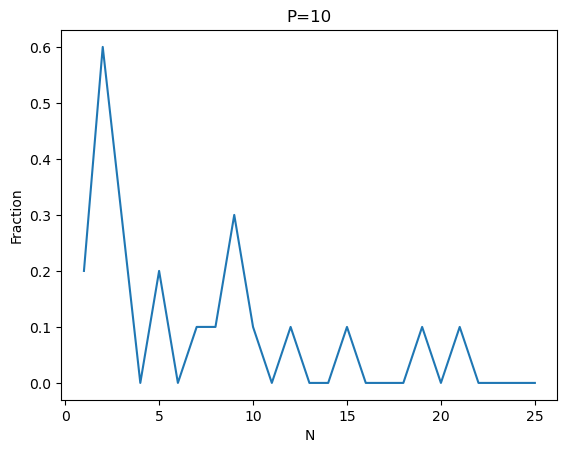

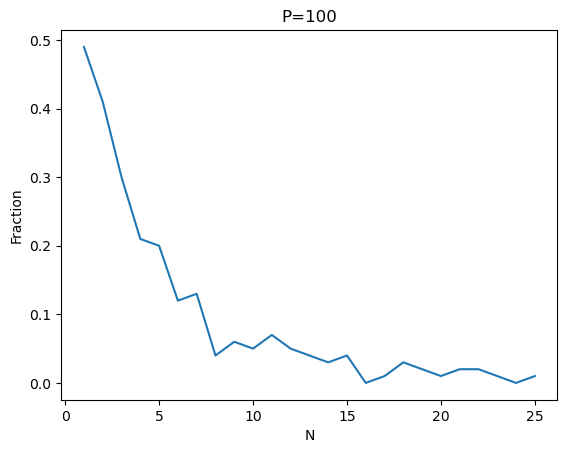

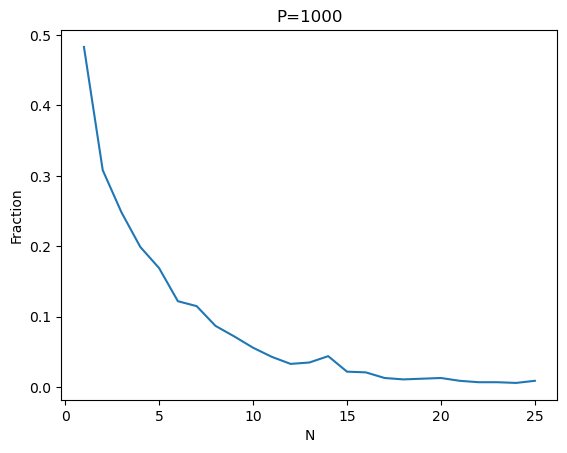

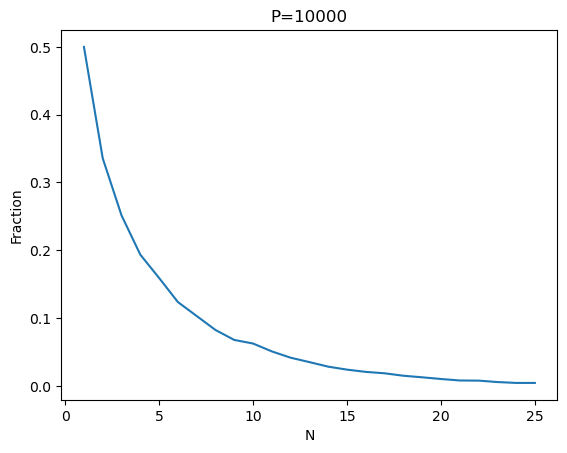

In [123]:
def g(w):
    return np.dot(w,w) + 2

for P in [10, 100, 1000, 10000]:
    num_samples=P
    wlist=[]
    for N in range (1,26):
        w=[0]*N
        w[0]=1
        w_dec=0
        
        directions=np.random.randn(num_samples,len(w))
        psum=np.sum(directions*directions,axis=1)
        norms=np.sqrt(psum)
        norms.shape=(num_samples,1)
        directions = directions/norms
        w_candidates=w + 1*directions
        gvals=[g(wval) for wval in w_candidates]
        for gw in gvals:
            if gw<g(w):
                w_dec+=1
        wlist.append(w_dec/P)
    plt.title('P='+str(P))
    plt.xlabel('N')
    plt.ylabel('Fraction')
    plt.plot(range (1,26),wlist)
    plt.show()
    

In [125]:
w=[1,2,3]
directions_plus = np.eye(np.size(w),np.size(w))
directions_minus = - np.eye(np.size(w),np.size(w))
directions = np.concatenate((directions_plus,directions_minus),axis=0)
print(directions)

[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]
 [-1. -0. -0.]
 [-0. -1. -0.]
 [-0. -0. -1.]]


In [134]:
# random search function
def coordinate_search(g,alpha_choice,max_its,w,num_samples):
    # run random search
    w_history = []         # container for w history
    cost_history = []           # container for corresponding cost function history
    alpha = 0
    
    for k in range(1,max_its+1):
        # check if diminishing steplength rule used
        if alpha_choice == 'diminishing':
            alpha = 1/float(k)
        else:
            alpha = alpha_choice
        directions_plus = np.eye(np.size(w),np.size(w))
        directions_minus = - np.eye(np.size(w),np.size(w))
        directions = np.concatenate((directions_plus,directions_minus),axis=0)
        w_candidates=w + alpha*directions
        gvals=[g(wval) for wval in w_candidates]
        ind=np.argmin(gvals)
        if g(w_candidates[ind])<g(w):
            w_history.append(w_candidates[ind])
            cost_history.append(g(w_candidates[ind]))
            w=w_candidates[ind]
            
        

        #weight_history.append(wr)
        #cost_history.append(cr)
    return w_history,cost_history



# random search function
def coordinate_descent(g,alpha_choice,max_its,w,num_samples):
    # run random search
    w_history = []         # container for w history
    cost_history = []           # container for corresponding cost function history
    alpha = 0
    
    for k in range(1,max_its+1):
        # check if diminishing steplength rule used
        if alpha_choice == 'diminishing':
            alpha = 1/float(k)
        else:
            alpha = alpha_choice
        directions_plus = np.eye(np.size(w),np.size(w))
        directions_minus = - np.eye(np.size(w),np.size(w))
        directions = np.concatenate((directions_plus,directions_minus),axis=0)
        w_candidates=w + alpha*directions
        for ind in np.random.permutation(len(directions)):
            if g(w_candidates[ind])<g(w):
                w_history.append(w_candidates[ind])
                cost_history.append(g(w_candidates[ind]))
                w=w_candidates[ind]
                break

    return w_history,cost_history

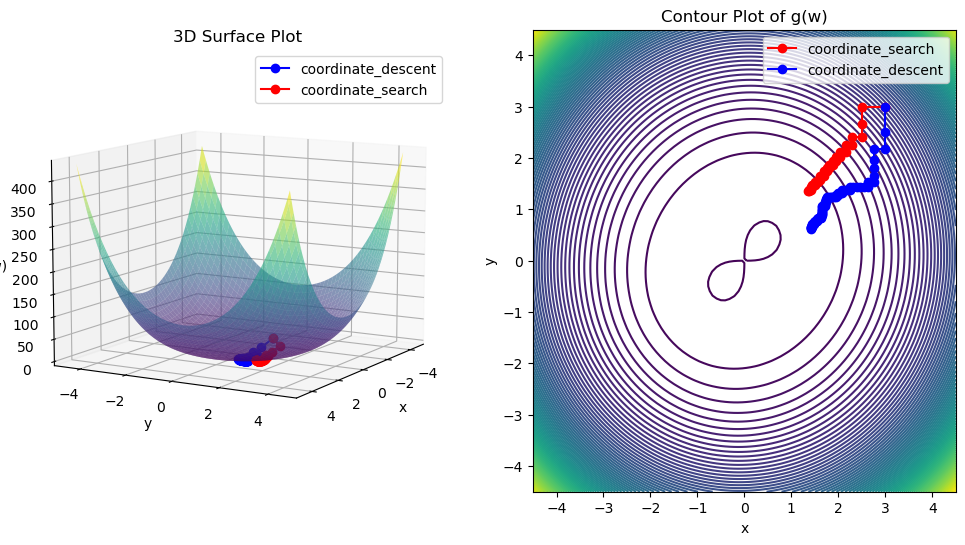

In [135]:
g = lambda w: 0.26*(w[1]**2 + w[0]**2 )**2 -0.48*w[0]*w[1]
alpha_choice = 'diminishing'; w = np.array([3,4]); num_samples = 1000; max_its = 40;
weight_history,cost_history = coordinate_search(g,alpha_choice,max_its,w,num_samples)
weight_history_k,cost_history_k = coordinate_descent(g,'diminishing',max_its*len(w),w,num_samples)
#static_plotter.two_input_surface_contour_plot(g,weight_history,view = [10,30],xmin = -4.5, xmax = 4.5, ymin = -4.5, ymax = 4.5)
x = np.linspace(-4.5, 4.5, 100)
y = np.linspace(-4.5, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.array([g(np.array([x_, y_])) for x_, y_ in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

# Create 3D and contour plots
fig = plt.figure(figsize=(12, 6))

# 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis')
ax1.set_title("3D Surface Plot")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('g(w)')
ax1.view_init(10, 30)

# Overlay weight history
history_x = [w[0] for w in weight_history]
history_y = [w[1] for w in weight_history]
history_z = [c for c in cost_history]
history_x_k = [w[0] for w in weight_history_k]
history_y_k = [w[1] for w in weight_history_k]
history_z_k = [c for c in cost_history_k]
ax1.plot(history_x_k, history_y_k, history_z_k, color='blue', marker='o', label='coordinate_descent')
ax1.plot(history_x, history_y, history_z, color='red', marker='o', label='coordinate_search')
ax1.legend()

# Contour Plot
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=100, cmap='viridis')
ax2.set_title("Contour Plot of g(w)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Overlay weight history
ax2.plot(history_x, history_y, color='red', marker='o', label='coordinate_search')
ax2.plot(history_x_k, history_y_k, color='blue', marker='o', label='coordinate_descent')

ax2.legend()

plt.show()

In [139]:
print( 'cost of coordinate_search:',cost_history[-1],'\ncost of coordinate_descent:', cost_history_k[-1])

cost of coordinate_search: 2.6767312083121393 
cost of coordinate_descent: 1.0583156910334708


In [142]:
csvname = 'student_debt_data.csv'
data = np.asarray(pd.read_csv(csvname,header = None))
y = data[:,1]
x = data[:,0]
x.shape = (len(x),1)
# pad input with ones
o = np.ones((len(x),1))
x_new = np.concatenate((o,x),axis = 1)

FileNotFoundError: [Errno 2] No such file or directory: 'student_debt_data.csv'